#**Procesamiento de imágenes digitales (Transformaciones de vecindario)**

## **Contenido**

[**1. Convolution**](#tema1)

[**2. Gaussian Filtering**](#tema2)

#Montar colab y moverse a la carpeta donde se encuentran las imágenes

In [94]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [95]:
%cd '/content/drive/MyDrive/UIS/2026-1/Procesamiento de imágenes dígitales/Quices/img'

[Errno 2] No such file or directory: '/content/drive/MyDrive/UIS/2026-1/Procesamiento de imágenes dígitales/Quices/img'
/content/drive/MyDrive/UIS/2026-1/Procesamiento de imágenes dígitales/Quices/img


# Librerias necesarias para la sesión

In [96]:
import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt

## <font color='#4C5FDA'>**Convolution**</font> <a name="tema1">

#Convolución 1D

In [97]:
def zero_pad(X, pad):
    X_pad = np.pad(X, pad, 'constant', constant_values=0)
    return X_pad

def conv_step(x, W):
    return np.sum(np.multiply(x, W))

def conv(s, k):
    diff = abs(len(s) - len(k) - 1)
    slide = len(k)
    # flip kernel
    k = k [::-1]
    Z = np.zeros(shape=len(s)-diff)
    for i in range(Z.shape[0]):
        Z[i] = conv_step(s[i:i+slide], k)
    return Z

In [98]:
# Probando convolución 1D
f = [1, 2, 3, 4]
h = [0.5, 0, -0.5]
print(np.convolve(f, h, 'same'))  # [ 1.   1.   1.  -1.5]
print(conv(zero_pad(f,1), h))  # [ 1.   1.   1.  -1.5]

[ 1.   1.   1.  -1.5]
[ 1.   1.   1.  -1.5]


In [99]:
zero_pad(f,1)

array([0, 1, 2, 3, 4, 0])

In [100]:
print(np.convolve(f, h))

[ 0.5  1.   1.   1.  -1.5 -2. ]


#Convolución 2D

# Reto: Implementar la convolución 2D "a mano" y comparar contra la función de OpenCV

In [101]:
def convolve(image, kernel):
		# Escriba aqui su codigo
		h_image, w_image = image.shape
		h_k, w_k = kernel.shape

		#Padding para "same"
		pad_h = (h_k-1) // 2
		pad_w = (w_k-1) // 2

		#Aplicar padding a la imagen
		image_conpad = np.zeros((h_image + 2 * pad_h, w_image + 2 * pad_w))
		image_conpad[pad_h:pad_h + h_image, pad_w:pad_w + w_image] = image

		output = np.zeros((h_image, w_image))

		kernel_volteado = kernel[::-1, ::-1]

		#convolución
		for i in range(h_image):
			for j in range(w_image):
				region = image_conpad[i:i + h_k, j:j + w_k]
				output[i, j] = np.sum(region * kernel_volteado)

		return output.astype("uint8") # retorne la imagen convolucionada en formato uint8

In [102]:
# box kernels
smallBlur = np.ones((7, 7), dtype="float") * (1.0 / (7 * 7))
largeBlur = np.ones((21, 21), dtype="float") * (1.0 / (21 * 21))

# Sobel kernel horizontal
sobelX = np.array((
	[-1, 0, 1],
	[-2, 0, 2],
	[-1, 0, 1]), dtype="int")

# Sobel kernel vertical
sobelY = np.array((
	[-1, -2, -1],
	[0, 0, 0],
	[1, 2, 1]), dtype="int")

# Laplacian kernel
laplacian = np.array((
	[0, 1, 0],
	[1, -4, 1],
	[0, 1, 0]), dtype="int")

# Laplacian kernel con diagonales
laplacianDiag = np.array((
	[1, 1, 1],
	[1, -8, 1],
	[1, 1, 1]), dtype="int")

# sharpening kernel
sharpen = np.array((
	[0, -1, 0],
	[-1, 5, -1],
	[0, -1, 0]), dtype="int")

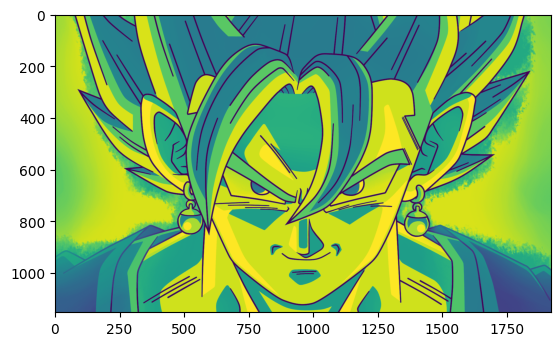

In [103]:
# load the input image and convert it to grayscale
image = cv.imread('vegito.png')
gray = cv.cvtColor(image, cv.COLOR_BGR2GRAY)
plt.imshow(gray)
plt.show()

(np.float64(-0.5), np.float64(1919.5), np.float64(1151.5), np.float64(-0.5))

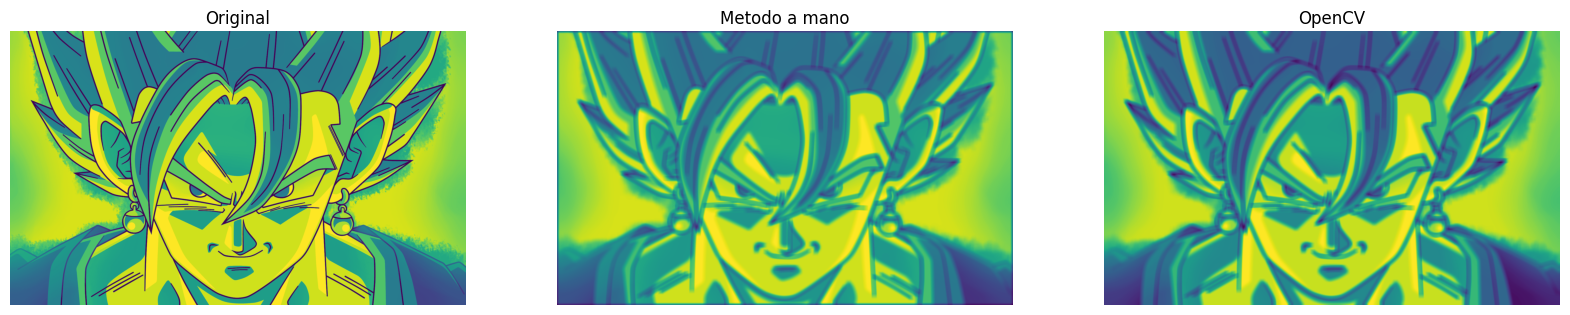

In [104]:
# Aplicar filtro y mostrar
convolveOutput = convolve(gray, largeBlur)
opencvOutput = cv.filter2D(gray, -1, largeBlur) # -1 se usa para mantener el mismo tamaño
plt.figure(figsize=(20,7))
plt.subplot(131), plt.imshow(gray), plt.title('Original'); plt.axis('off') #plt.colorbar();
plt.subplot(132), plt.imshow(convolveOutput), plt.title('Metodo a mano'); plt.axis('off') #plt.colorbar();
plt.subplot(133), plt.imshow(opencvOutput), plt.title('OpenCV'); plt.axis('off') #plt.colorbar();

# Prueba con los otros filtros y confirma que quedó bien implementado tu método

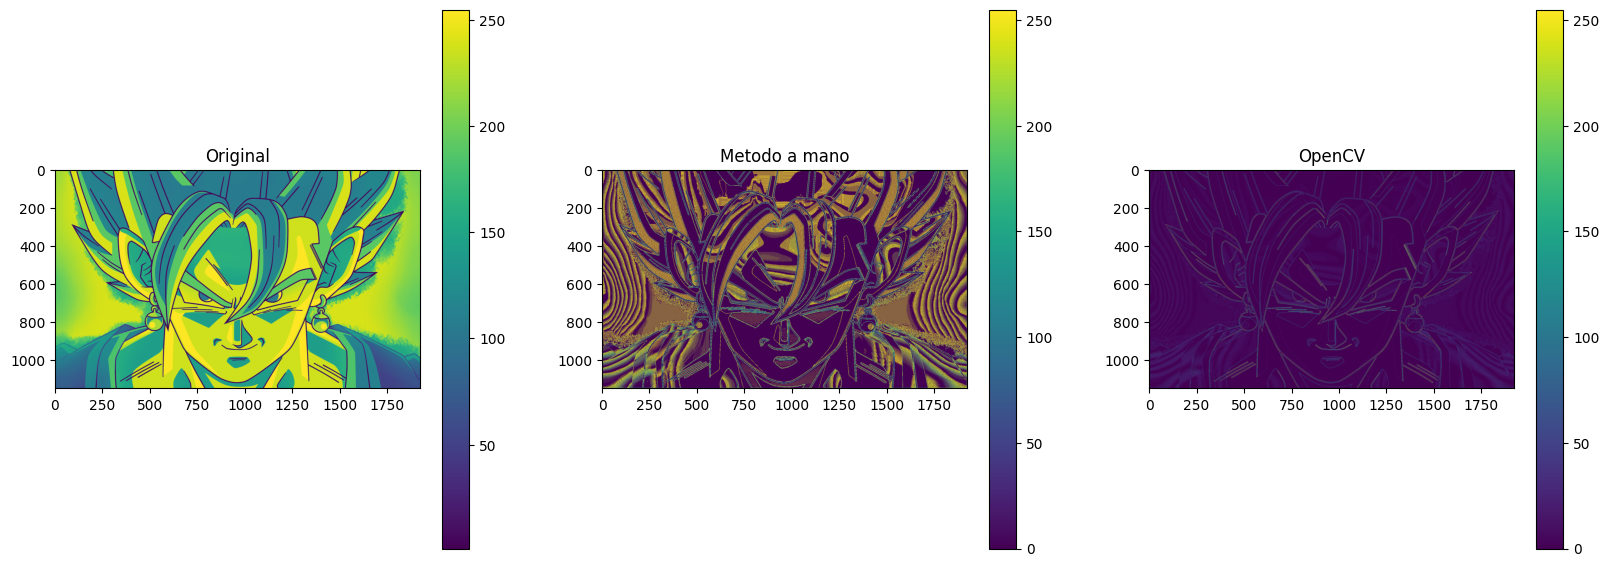

In [105]:
# Aplicar filtro y mostrar
convolveOutput = convolve(gray, laplacian)
opencvOutput = cv.filter2D(gray, -1, laplacian)
plt.figure(figsize=(20,7))
plt.subplot(131), plt.imshow(gray), plt.title('Original'); plt.colorbar();
plt.subplot(132), plt.imshow(convolveOutput), plt.title('Metodo a mano'); plt.colorbar();
plt.subplot(133), plt.imshow(opencvOutput), plt.title('OpenCV'); plt.colorbar();

## <font color='#4C5FDA'>**Gaussian Filtering**</font> <a name="tema2">

In [106]:
def gaussian_kernel(sample_range=5, sigma=1):
    """\
    creates gaussian kernel with side length `l` and a sigma of `sig`
    """
    ax = np.linspace(-(sample_range - 1) / 2., (sample_range - 1) / 2., sample_range)
    xx, yy = np.meshgrid(ax, ax)
    gauss = np.exp(-(xx ** 2 + yy ** 2) / (2 * sigma **2))
    return gauss / np.sum(gauss)

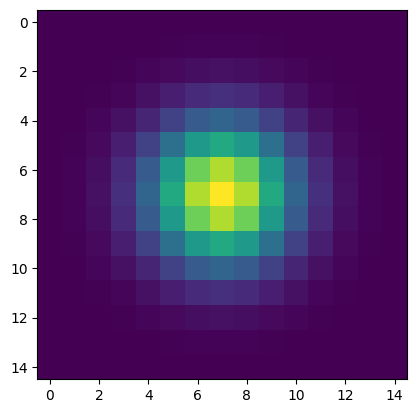

In [107]:
kernel = gaussian_kernel(15, 2)
plt.imshow(kernel)
plt.show()

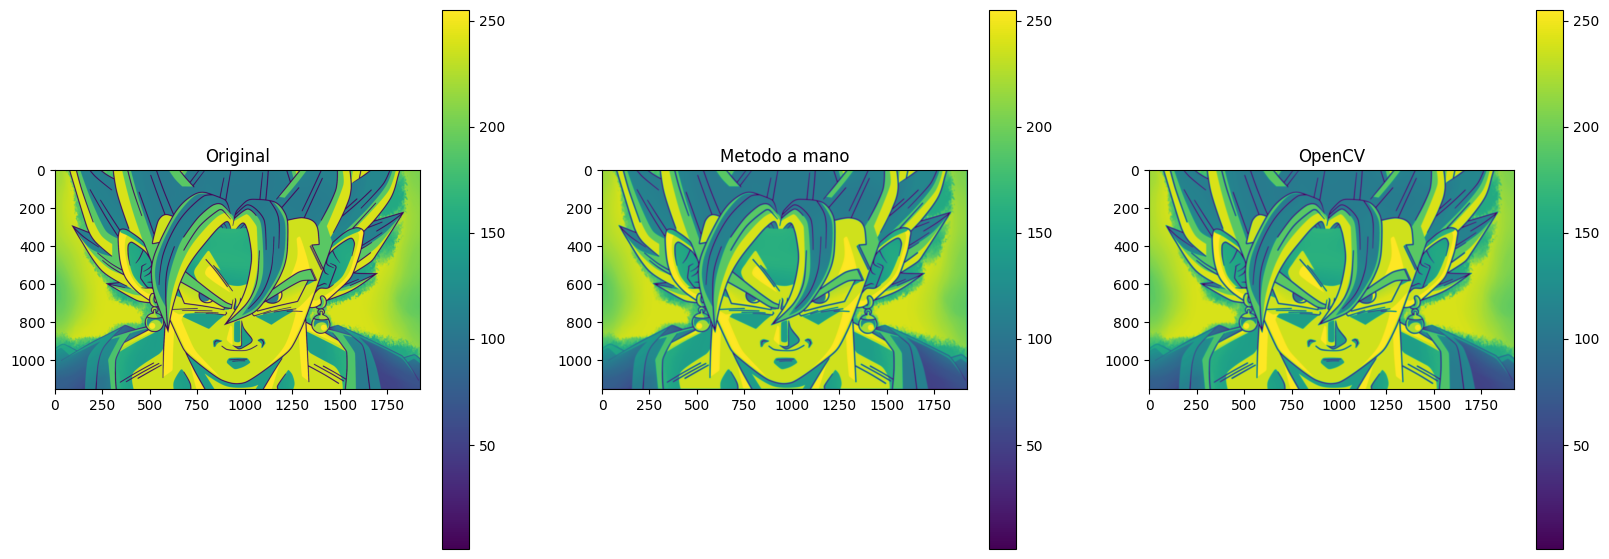

In [108]:
convolveOutput = convolve(gray, kernel)
opencvOutput = cv.filter2D(gray, -1, kernel)
# show the output images
plt.figure(figsize=(20,7))
plt.subplot(131), plt.imshow(gray), plt.title('Original'); plt.colorbar();
plt.subplot(132), plt.imshow(convolveOutput), plt.title('Metodo a mano'); plt.colorbar();
plt.subplot(133), plt.imshow(opencvOutput), plt.title('OpenCV'); plt.colorbar();

# Agregando ruido blanco

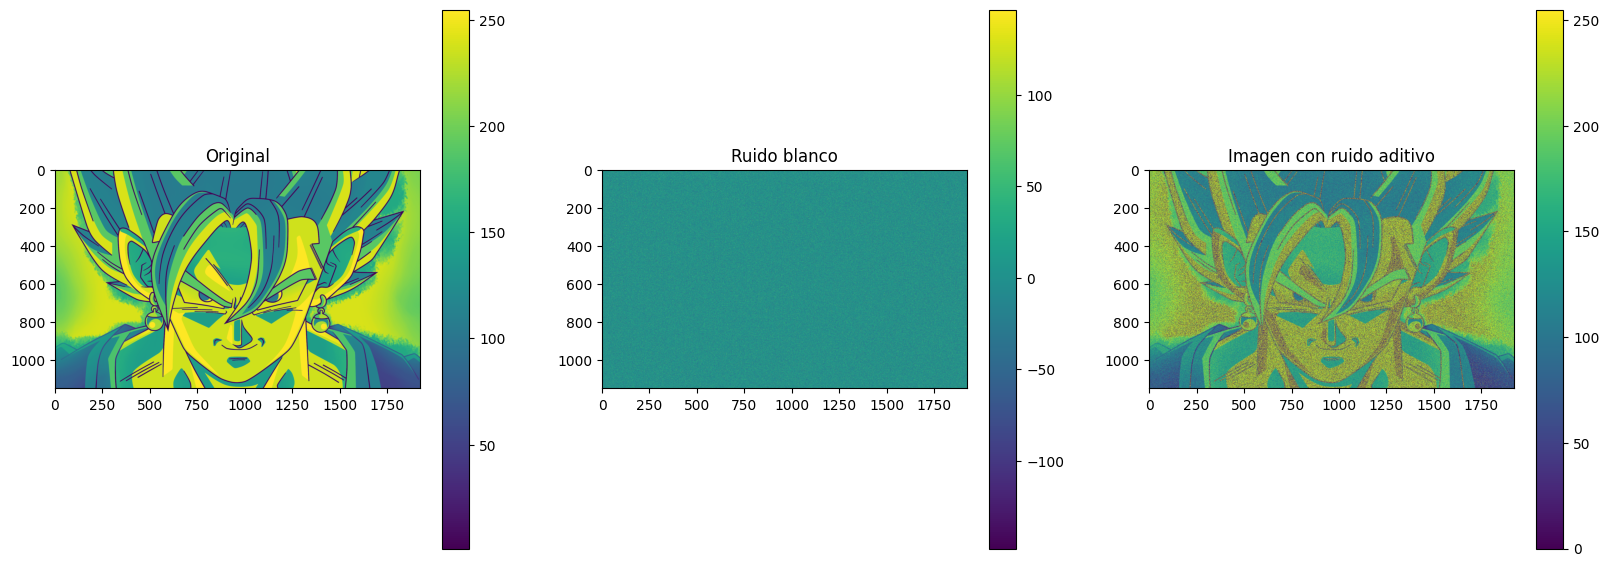

In [109]:
NOISE_STD = 30

noise = np.random.normal(scale=NOISE_STD, size=gray.shape)
noisy_image = (gray + noise).astype('uint8')

plt.figure(figsize=(20,7))
plt.subplot(131), plt.imshow(gray), plt.title('Original'); plt.colorbar();
plt.subplot(132), plt.imshow(noise), plt.title('Ruido blanco'); plt.colorbar();
plt.subplot(133), plt.imshow(noisy_image), plt.title('Imagen con ruido aditivo'); plt.colorbar();

Filtrando el ruido usando filtro promedio

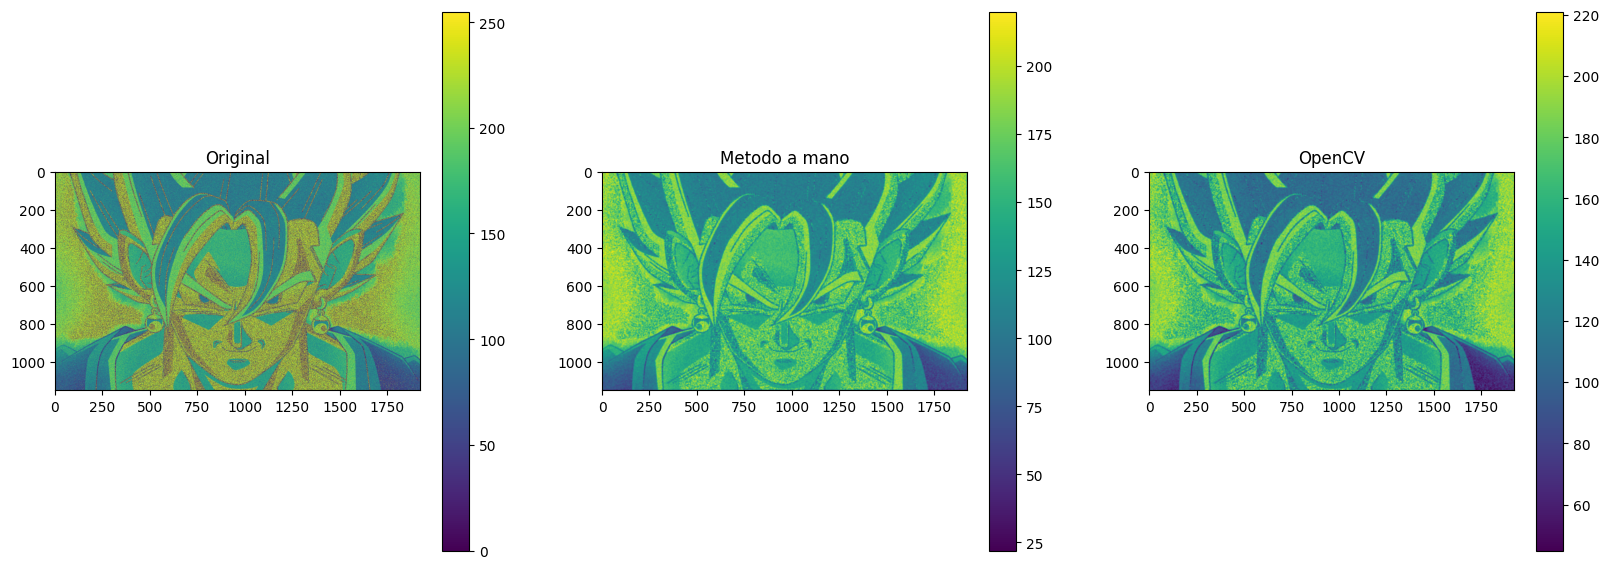

In [110]:
convolveOutput = convolve(noisy_image, kernel)
opencvOutput = cv.filter2D(noisy_image, -1, kernel)
# show the output images
plt.figure(figsize=(20,7))
plt.subplot(131), plt.imshow(noisy_image), plt.title('Original'); plt.colorbar();
plt.subplot(132), plt.imshow(convolveOutput), plt.title('Metodo a mano'); plt.colorbar();
plt.subplot(133), plt.imshow(opencvOutput), plt.title('OpenCV'); plt.colorbar();